# KPIs Mensuales de Red Telecom: Barras de Uso de Datos con Líneas de ARPU y Abandono (PROC GBARLINE)

## Resumen Ejecutivo

Este cuaderno usa **PROC GBARLINE** para combinar un gráfico de barras verticales del uso mensual de datos móviles con gráficos de línea superpuestos de ARPU, abandono y tickets de soporte — el clásico panel de KPIs de "dos ejes" que un analista de telecomunicaciones construye para detectar si el aumento del uso realmente se traduce en ingresos y retención. Genera registros sintéticos por suscriptor en línea, y luego ejercita las instrucciones BAR y LINE con subgrupos, ejes derechos personalizados, símbolos de referencia y leyendas.

## Fuentes de Datos

**Conjunto de datos: `telco_kpi`** — registros sintéticos por suscriptor-mes (4 meses x 3 niveles de plan x 8 suscriptores = 96 filas), generados en línea con `call streaminit(20260531)`. El panel se mantiene en 96 filas para que quepa cómodamente dentro del límite de 100 observaciones del modo sin licencia, dejando cada mes y nivel de plan totalmente poblado.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `month`  | Char | Etiqueta de mes calendario (Ene–Abr) |
| `plan`   | Char | Nivel de plan: Prepago, Pospago, Familiar |
| `data_gb`| Num  | Datos móviles mensuales consumidos, en GB (distribución gamma, con un ligero repunte estacional y crecimiento lento) |
| `arpu`   | Num  | Ingreso promedio por usuario, en USD (aumenta con el nivel de plan y a lo largo de los meses) |
| `churn`  | Num  | Indicador de abandono mensual (0/1, Bernoulli; más alto al principio del período y en niveles más bajos) |
| `tickets`| Num  | Tickets de soporte abiertos (conteo Poisson) |

# KPIs Mensuales de Red Telecom con PROC GBARLINE

Los operadores de telecomunicaciones viven y mueren por un puñado de KPIs mensuales: cuántos **datos** consumen los suscriptores, el **ARPU** (ingreso promedio por usuario) que genera ese consumo, cuántos clientes se **dan de baja**, y la carga de **tickets de soporte** detrás de todo esto. Estas métricas viven en escalas muy diferentes — gigabytes, dólares y conteos pequeños — así que graficarlas en un solo eje de respuesta oculta la historia.

`PROC GBARLINE` está construido exactamente para esto: dibuja un gráfico de **barras** verticales contra el eje izquierdo y superpone uno o más gráficos de **línea** contra un eje derecho independiente. En este cuaderno construimos un panel de uso frente a ingresos, y luego agregamos progresivamente subgrupos a nivel de plan, un eje derecho personalizado y superposiciones de múltiples líneas.

## Paso 1 — Generar datos sintéticos por suscriptor-mes

El paso DATA a continuación fabrica un panel realista: 4 meses (Ene–Abr) en 3 niveles de plan (Prepago, Pospago, Familiar) con 8 suscriptores cada uno, para 96 filas en total. Sembramos el generador de números aleatorios con `call streaminit` para reproducibilidad y extraemos cada KPI de una distribución apropiada al dominio:

- **Uso de datos** de una distribución gamma con un ligero repunte estacional y crecimiento lento mes a mes.
- **ARPU** que aumenta con el nivel de plan y a lo largo de los meses, con ruido normal.
- **Abandono** como un indicador Bernoulli que es más alto al principio del período y en niveles más económicos.
- **Tickets de soporte** como conteos Poisson, ligeramente más pesados al principio.

No se leen archivos externos — todo es autocontenido, y el panel de 96 filas permanece dentro del límite sin licencia de 100 observaciones para que se renderice cada mes y nivel.

In [1]:
DATOS telco_kpi;
    LLAMAR streaminit(20260531);
    LONGITUD month $3 plan $8;
    ARREGLO mname[4] $3 _temporary_
        ('Ene' 'Feb' 'Mar' 'Abr');
    HACER mi = 1 HASTA 4;
        month = mname[mi];
        /* ligero repunte estacional y crecimiento lento de datos */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        HACER plan_i = 1 HASTA 3;
            SI plan_i = 1 ENTONCES plan = 'Prepago';
            SINO SI plan_i = 2 ENTONCES plan = 'Pospago';
            SINO plan = 'Familiar';
            HACER rep = 1 HASTA 8;
                /* datos moviles mensuales consumidos (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* ingreso promedio por usuario ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* indicador de abandono mensual, mas alto al inicio del ano */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* tickets de soporte abiertos */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                SALIDA;
            END;
        END;
    END;
    ELIMINAR mi plan_i rep season mname:;
EJECUTAR;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Paso 2 — El panel central: barras de uso + línea de ARPU

Este es el patrón canónico de `GBARLINE`. La instrucción `BAR` grafica el uso medio mensual de datos (`SUMVAR=data_gb TYPE=mean`), y una sola instrucción `LINE` superpone el ARPU medio en el eje derecho (`STAT=mean TYPE=join`). Activamos ODS Graphics y le damos al gráfico un título de dos líneas. `COUTLINE=` y `WIDTH=` afinan las barras.

                                          Uso Mensual de Datos Moviles y ARPU                                           
                                      KPIs sinteticos de red de telecomunicaciones                                      




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Uso Mensual de Datos Moviles y ARPU.
NOTE: Option TITLE2 changed to KPIs sinteticos de red de telecomunicaciones.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


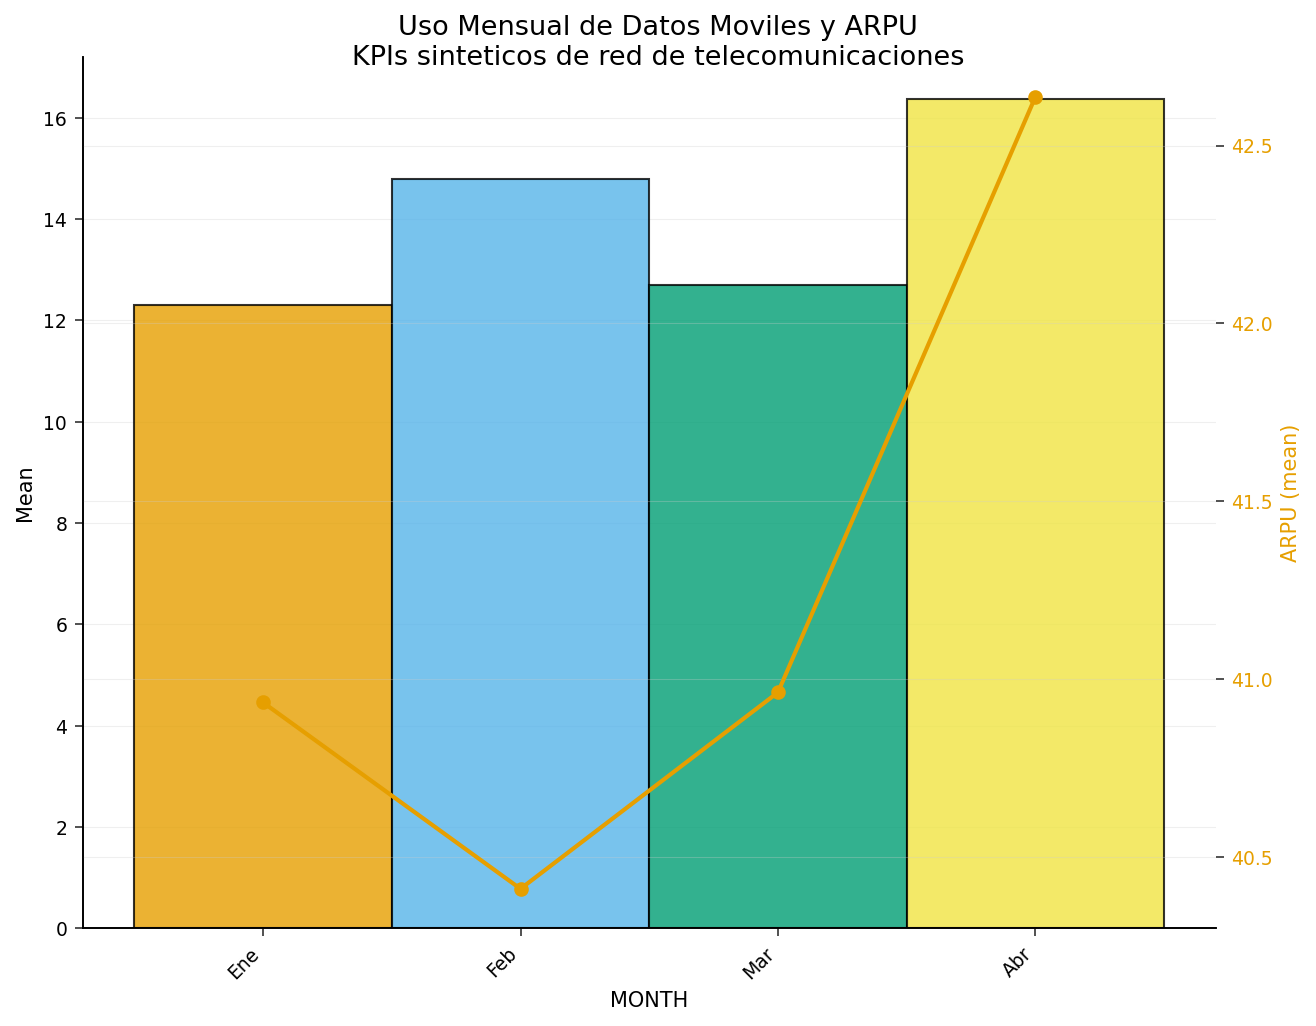

In [2]:
ODS GRAPHICS ON;
TÍTULO 'Uso Mensual de Datos Moviles y ARPU';
title2 'KPIs sinteticos de red de telecomunicaciones';

PROCEDIMIENTO gbarline DATOS=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
EJECUTAR;

## Paso 3 — Desglosar el uso por plan, superponer el abandono

Reemplazar `TYPE=mean` por `TYPE=sum` y agregar `SUBGROUP=plan` apila la barra de cada mes por nivel de plan, para que podamos ver qué segmento impulsa el volumen total. La `LINE` superpuesta ahora grafica el **conteo** mensual de eventos de abandono como un gráfico de agujas (`STAT=sum TYPE=needle`) — picos verticales que se leen naturalmente como conteos de eventos discretos en lugar de una tendencia suave.

                                     Volumen de Datos por Plan con Abandono Mensual                                     
                                      KPIs sinteticos de red de telecomunicaciones                                      




NOTE: Option TITLE changed to Volumen de Datos por Plan con Abandono Mensual.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


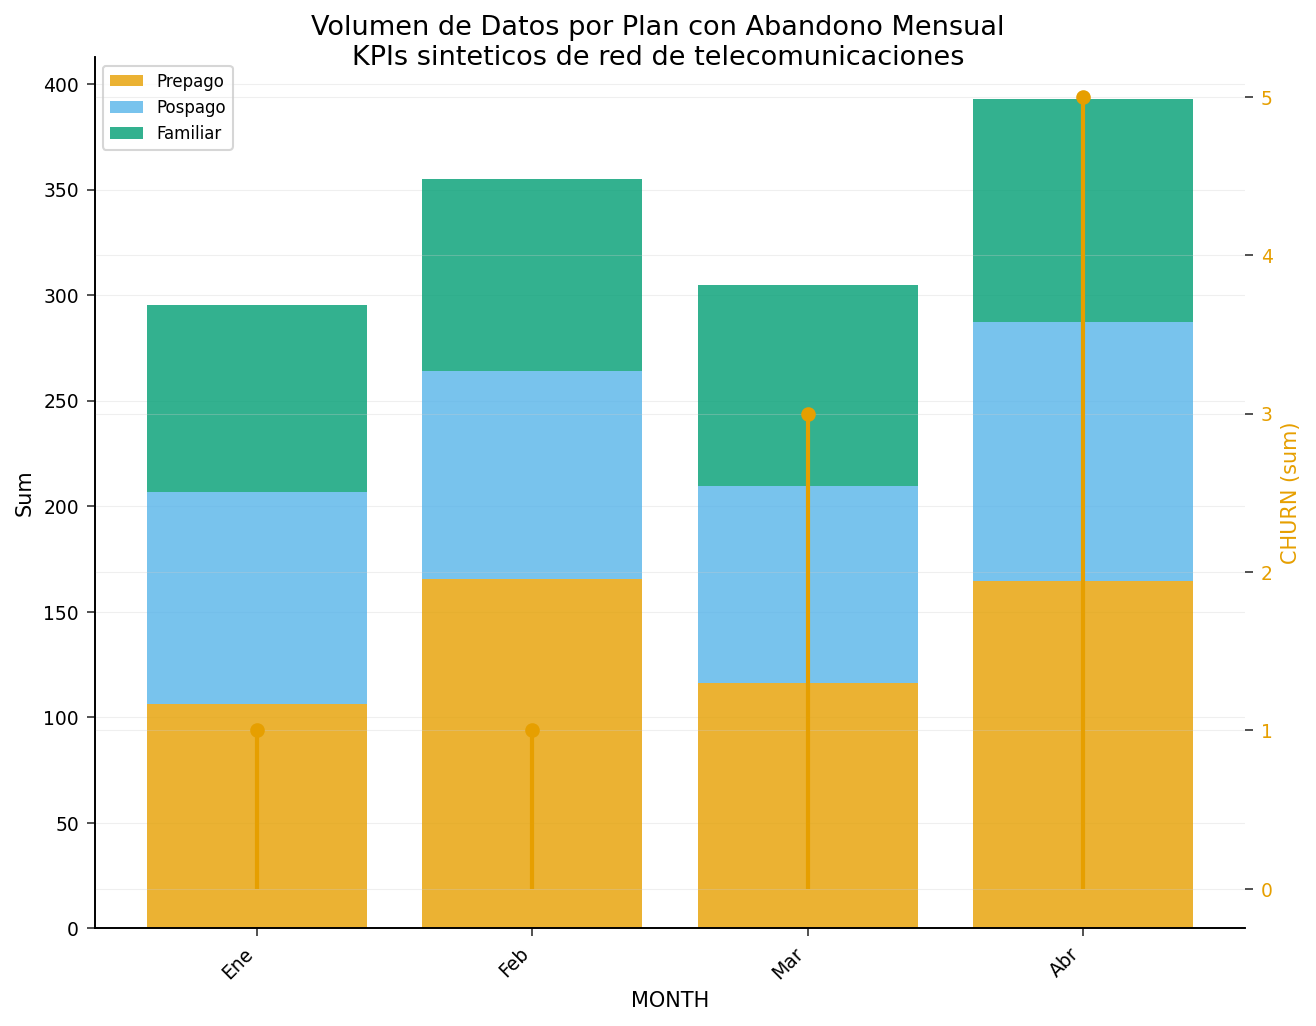

In [3]:
TÍTULO 'Volumen de Datos por Plan con Abandono Mensual';

PROCEDIMIENTO gbarline DATOS=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
EJECUTAR;

## Paso 4 — Controlar el eje derecho y el marcador de línea

Para un gráfico listo para publicación fijamos el eje del gráfico (derecho) a un rango fijo con una definición `AXIS` y lo etiquetamos, luego lo vinculamos a la línea mediante `RAXIS=axis2`. Una definición `SYMBOL` le da a la línea de ARPU un marcador punteado rojo. También mostramos los totales de barra encima de cada barra con `OUTSIDE=sum`.

                                        Uso Total (barras) vs ARPU Medio (linea)                                        
                                      KPIs sinteticos de red de telecomunicaciones                                      




NOTE: Option TITLE changed to Uso Total (barras) vs ARPU Medio (linea).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


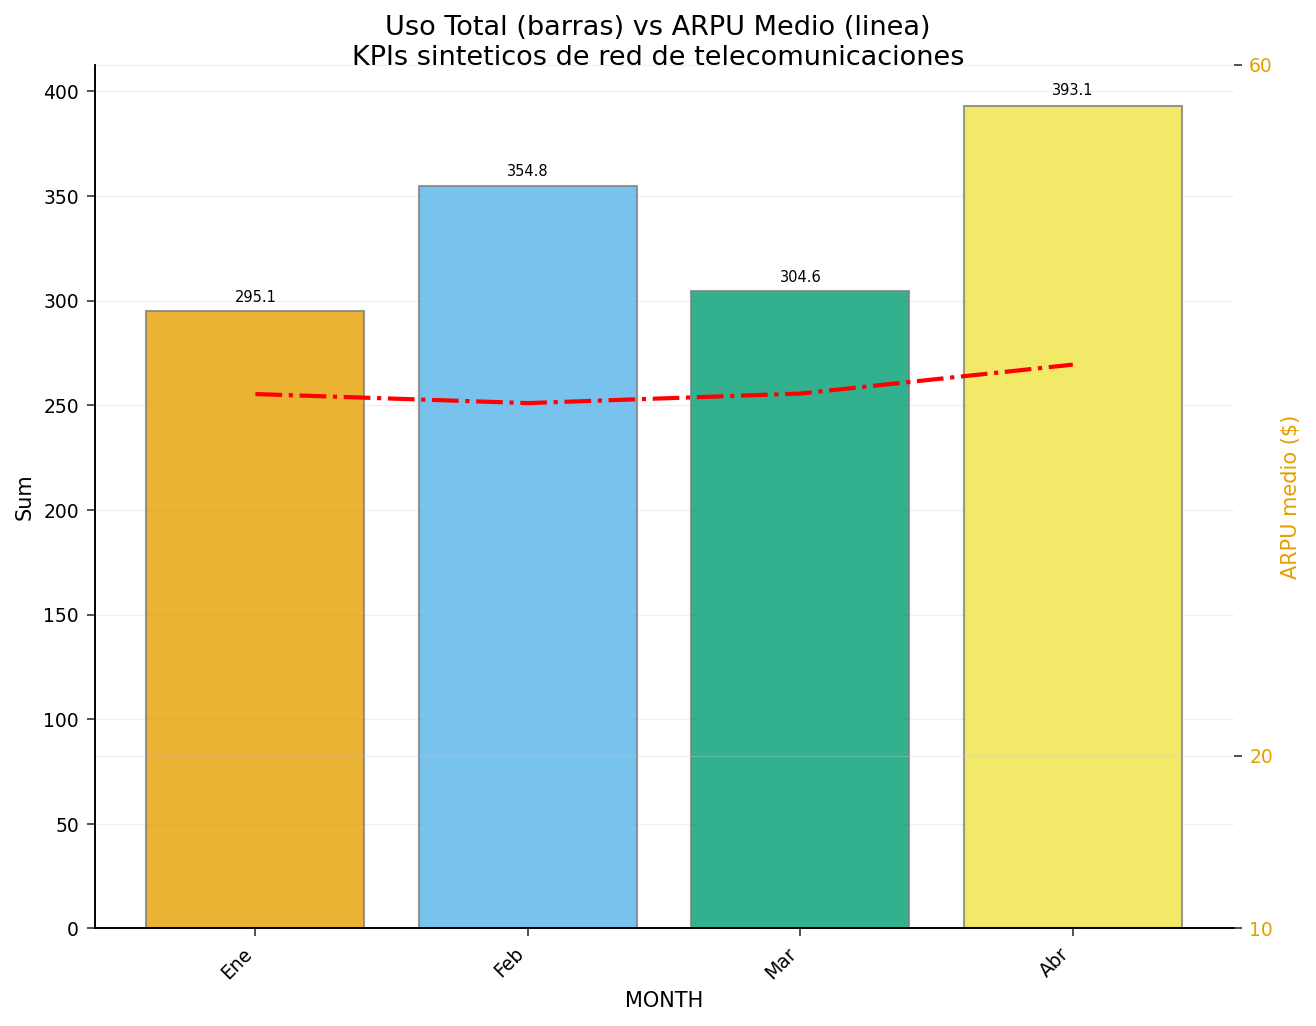

In [4]:
TÍTULO 'Uso Total (barras) vs ARPU Medio (linea)';

PROCEDIMIENTO gbarline DATOS=telco_kpi;
    axis2 ORDER=(20 HASTA 60 POR 10) ETIQUETA=('ARPU medio ($)');
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
EJECUTAR;

## Paso 5 — Múltiples superposiciones de línea con una leyenda personalizada

`GBARLINE` acepta más de una instrucción `LINE`, así que podemos comparar dos señales operativas contra las barras de uso a la vez: tickets de soporte medios (`type=join`) y abandono total (`type=needle`). Una definición `LEGEND` posicionada abajo documenta los subgrupos de plan.

                                      Tendencias de Tickets de Soporte y Abandono                                       
                                      KPIs sinteticos de red de telecomunicaciones                                      




NOTE: Option TITLE changed to Tendencias de Tickets de Soporte y Abandono.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


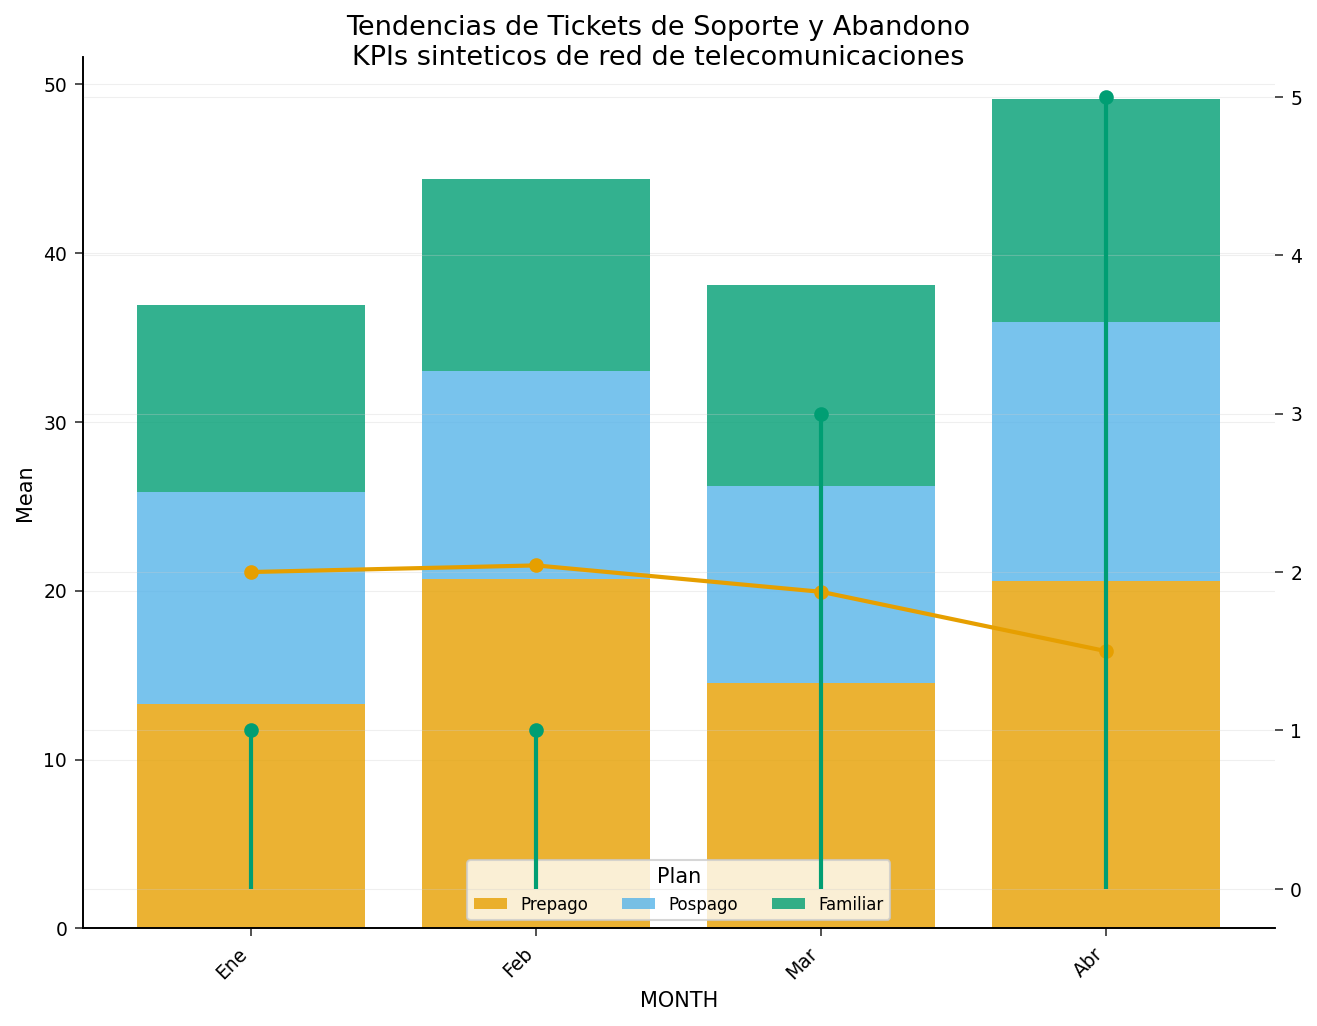

In [5]:
TÍTULO 'Tendencias de Tickets de Soporte y Abandono';

PROCEDIMIENTO gbarline DATOS=telco_kpi;
    legend1 ETIQUETA=('Plan') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
EJECUTAR;

ODS GRAPHICS OFF;

## Interpretación de los resultados

A lo largo de la ventana de Ene–Abr, el panel cuenta una historia coherente de telecomunicaciones. El **uso de datos** (las barras) es irregular mes a mes pero tiende al alza, alcanzando su punto máximo en **abril** — el uso medio sube de unos 12.3 GB en enero a 16.4 GB en abril (Paso 2), y el volumen total de 295 GB a 393 GB (las etiquetas `OUTSIDE=sum` en el Paso 4). La **línea de ARPU** cae ligeramente en febrero y luego sube hasta su propio máximo de abril cerca de \$42.6, así que el operador está monetizando cada vez más el consumo adicional en lugar de regalarlo — el eje derecho en el Paso 4 está fijado en \$20–\$60 para mantener ese movimiento legible.

Las vistas apiladas por plan (Pasos 3 y 5) revelan la tensión de segmento que define a los operadores con predominio de prepago. **Prepago** (la banda naranja) lleva la mayor cantidad de gigabytes en general — unos 553 GB a lo largo de los cuatro meses frente a 415 GB para Pospago y 380 GB para Familiar — pero gana el **menor** ingreso promedio por usuario (unos \$36, contra \$41 para Pospago y \$47 para Familiar). Las **agujas de abandono** confirman dónde se sitúa el riesgo de retención: los eventos de abandono se concentran en los niveles Prepago y Pospago (4 eventos cada uno durante la ventana) y se mantienen más ligeros en Familiar (2), y crecen hacia abril a medida que la base de suscriptores y el uso se expanden.

El Paso 5 superpone la carga operativa sobre esto: los **tickets de soporte** medios corren un poco más pesados al principio del período y se alivian hacia abril, mientras que las agujas de abandono alcanzan su pico más tarde — el tipo de señal que un equipo de retención vigila. Operativamente, la lectura es concentrar el gasto de retención en los suscriptores **Prepago**, quienes consumen la porción de volumen de datos de más rápido crecimiento mientras generan el menor ingreso y el mayor abandono.

`PROC GBARLINE` es la herramienta adecuada aquí precisamente porque mantiene las barras a escala de gigabytes y las líneas a escala de dólares/conteos en ejes independientes, permitiendo que cada KPI se lea en sus propios términos mientras aún comparte el eje de tiempo mensual.